# 🔍 Notebook 6 — Model Monitoring & Drift Detection

## Coal Demand Forecasting — CRISP-ML(Q) Framework

**Objective:** Implement post-deployment monitoring to ensure the best model remains reliable over time.

### What this notebook covers:
1. **Data Drift Detection** — Kolmogorov-Smirnov (KS) test on features
2. **Model Performance Degradation** — MAPE monitoring over rolling windows
3. **Monitoring Dashboard** — Summary table with pass/fail indicators
4. **Alerting Logic** — When to retrain the model

---

## 6.1 Setup

In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

from src.config import (
    PROCESSED_TRAIN_FILE, PROCESSED_VAL_FILE, PROCESSED_TEST_FILE,
    TARGET_MAPE
)

train_df = pd.read_csv(PROCESSED_TRAIN_FILE)
val_df = pd.read_csv(PROCESSED_VAL_FILE)
test_df = pd.read_csv(PROCESSED_TEST_FILE)

# Derive feature columns (all numeric except date and target)
FEATURE_COLUMNS = [c for c in train_df.columns
                   if c not in ['date', 'coal_consumption_tonnes']
                   and train_df[c].dtype in ['float64', 'int64', 'float32', 'int32']]

print(f'Train shape: {train_df.shape}')
print(f'Val shape:   {val_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'Features monitored: {len(FEATURE_COLUMNS)}')

Train shape: (746, 30)
Val shape:   (160, 30)
Test shape:  (160, 30)
Features monitored: 28


## 6.2 Data Drift Detection — KS Test

The **Kolmogorov-Smirnov (KS) test** checks whether the distribution of features has shifted between training and test data.

- **Null hypothesis:** Train and test distributions are the same
- **Threshold:** p-value < 0.05 indicates statistically significant drift
- **Implication:** Drifted features may cause model performance degradation

In [2]:
def detect_data_drift(train_df, test_df, feature_columns, threshold=0.05):
    """KS-test based data drift detection."""
    drift_results = []
    for col in feature_columns:
        if col in train_df.columns and col in test_df.columns:
            train_vals = train_df[col].dropna().values
            test_vals = test_df[col].dropna().values
            if len(train_vals) > 0 and len(test_vals) > 0:
                ks_stat, p_value = ks_2samp(train_vals, test_vals)
                drift_detected = p_value < threshold
                drift_results.append({
                    'Feature': col,
                    'KS Statistic': round(ks_stat, 4),
                    'p-value': round(p_value, 6),
                    'Drift Detected': drift_detected,
                    'Status': '⚠️ DRIFT' if drift_detected else '✅ Stable'
                })
    return pd.DataFrame(drift_results)

drift_df = detect_data_drift(train_df, test_df, FEATURE_COLUMNS)
print(f"Features checked: {len(drift_df)}")
print(f"Features with drift: {drift_df['Drift Detected'].sum()}")
print(f"Features stable: {(~drift_df['Drift Detected']).sum()}")

Features checked: 28
Features with drift: 21
Features stable: 7


In [3]:
# Display drift results table
print("╔══════════════════════════════╦════════════╦══════════════╦══════════════╗")
print("║ Feature                      ║ KS Stat    ║   p-value    ║ Status       ║")
print("╠══════════════════════════════╬════════════╬══════════════╬══════════════╣")

for _, row in drift_df.iterrows():
    print(f"║ {row['Feature']:<28} ║ {row['KS Statistic']:>10.4f} ║ {row['p-value']:>12.6f} ║ {row['Status']:<12} ║")

print("╚══════════════════════════════╩════════════╩══════════════╩══════════════╝")

# Also display as styled DataFrame
display(drift_df.style.applymap(
    lambda x: 'background-color: #f8d7da' if x == '⚠️ DRIFT' else ('background-color: #d4edda' if x == '✅ Stable' else ''),
    subset=['Status']
).set_caption('Data Drift Detection Results (KS Test)'))

╔══════════════════════════════╦════════════╦══════════════╦══════════════╗
║ Feature                      ║ KS Stat    ║   p-value    ║ Status       ║
╠══════════════════════════════╬════════════╬══════════════╬══════════════╣
║ power_generation_mw          ║     0.2281 ║     0.000002 ║ ⚠️ DRIFT     ║
║ temperature_c                ║     0.0962 ║     0.162294 ║ ✅ Stable     ║
║ coal_price_inr               ║     0.9611 ║     0.000000 ║ ⚠️ DRIFT     ║
║ inventory_level_tonnes       ║     0.0285 ║     0.999795 ║ ✅ Stable     ║
║ is_holiday                   ║     0.0187 ║     1.000000 ║ ✅ Stable     ║
║ is_weekend                   ║     0.0033 ║     1.000000 ║ ✅ Stable     ║
║ month                        ║     0.5461 ║     0.000000 ║ ⚠️ DRIFT     ║
║ quarter                      ║     0.5067 ║     0.000000 ║ ⚠️ DRIFT     ║
║ day_of_week                  ║     0.0053 ║     1.000000 ║ ✅ Stable     ║
║ day_of_year                  ║     0.5737 ║     0.000000 ║ ⚠️ DRIFT     ║
║ week_of_ye

,Feature,KS Statistic,p-value,Drift Detected,Status
0,power_generation_mw,0.228100,0.000002,True,⚠️ DRIFT
1,temperature_c,0.096200,0.162294,False,✅ Stable
2,coal_price_inr,0.961100,0.000000,True,⚠️ DRIFT
3,inventory_level_tonnes,0.028500,0.999795,False,✅ Stable
4,is_holiday,0.018700,1.000000,False,✅ Stable
5,is_weekend,0.003300,1.000000,False,✅ Stable
6,month,0.546100,0.000000,True,⚠️ DRIFT
7,quarter,0.506700,0.000000,True,⚠️ DRIFT
8,day_of_week,0.005300,1.000000,False,✅ Stable
9,day_of_year,0.573700,0.000000,True,⚠️ DRIFT


## 6.3 Drift Visualization

Visualizing the KS statistic and p-values for all features.

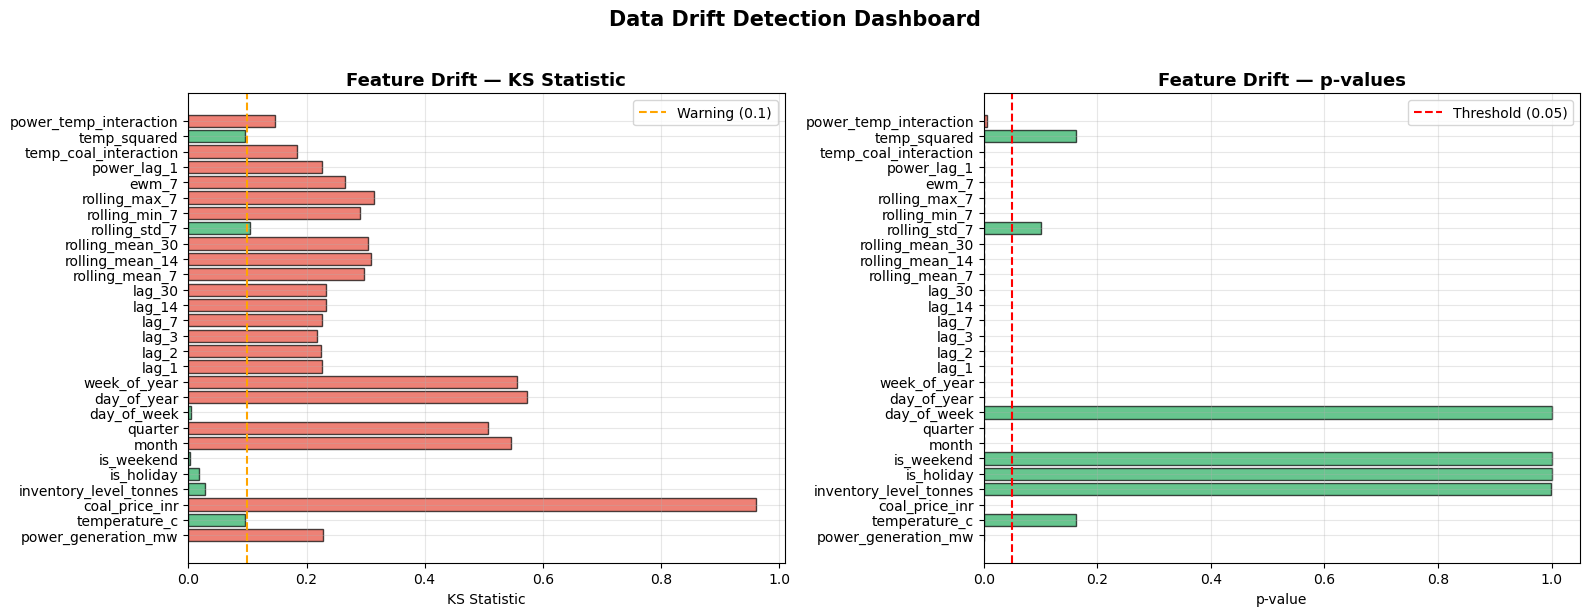

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KS Statistic bar chart
colors = ['#E74C3C' if d else '#27AE60' for d in drift_df['Drift Detected']]
axes[0].barh(drift_df['Feature'], drift_df['KS Statistic'], color=colors, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.1, color='orange', linestyle='--', label='Warning (0.1)')
axes[0].set_xlabel('KS Statistic')
axes[0].set_title('Feature Drift — KS Statistic', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# p-value bar chart (log scale)
axes[1].barh(drift_df['Feature'], drift_df['p-value'], color=colors, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.05, color='red', linestyle='--', label='Threshold (0.05)')
axes[1].set_xlabel('p-value')
axes[1].set_title('Feature Drift — p-values', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Data Drift Detection Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6.4 Distribution Comparison — Drifted Features

For any features that show drift, we compare their train vs test distributions side-by-side.

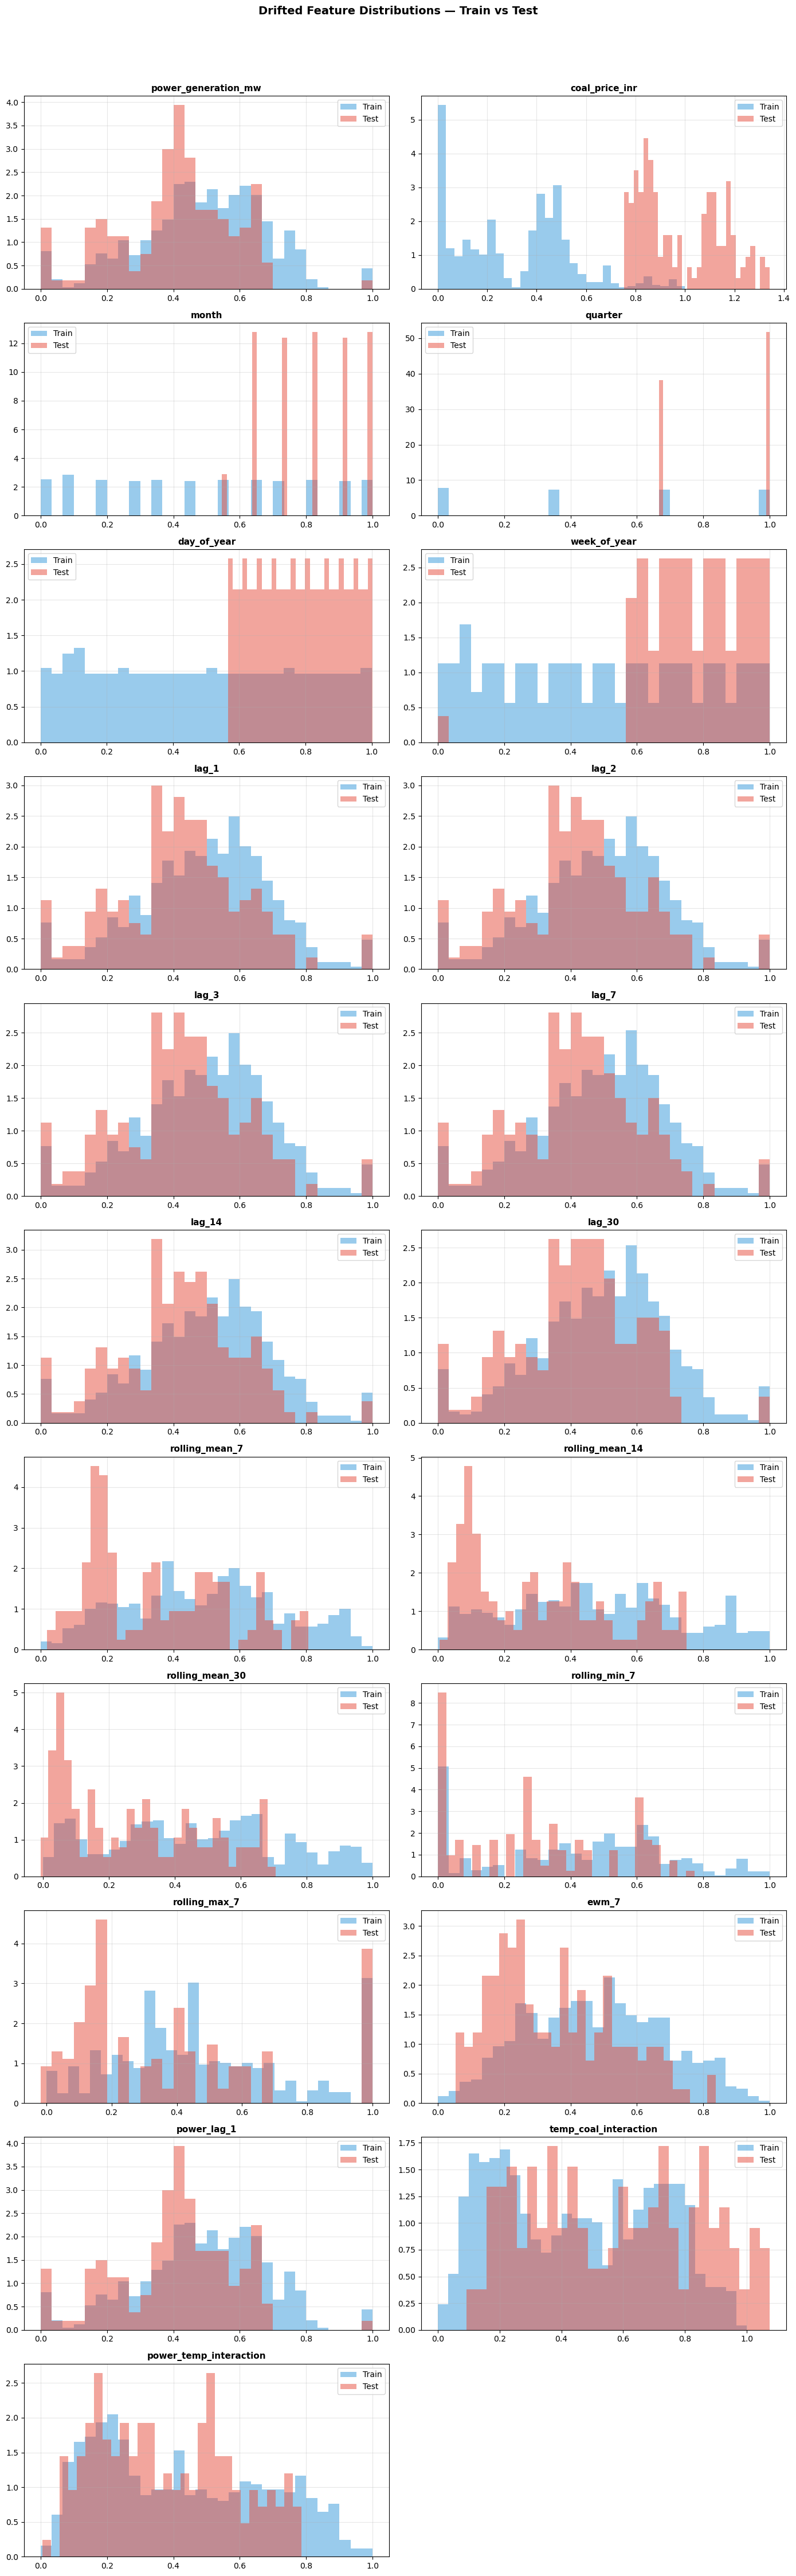

In [5]:
drifted_features = drift_df[drift_df['Drift Detected']]['Feature'].tolist()
plot_features = drifted_features if len(drifted_features) > 0 else drift_df['Feature'].head(4).tolist()

n_cols = min(2, len(plot_features))
n_rows = (len(plot_features) + n_cols - 1) // n_cols
n_rows = max(1, n_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
if n_rows * n_cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

title_prefix = 'Drifted' if len(drifted_features) > 0 else 'Sample'

for idx, feat in enumerate(plot_features):
    if idx >= len(axes):
        break
    ax = axes[idx]
    if feat in train_df.columns:
        ax.hist(train_df[feat].dropna(), bins=30, alpha=0.5, color='#3498DB', label='Train', density=True)
    if feat in test_df.columns:
        ax.hist(test_df[feat].dropna(), bins=30, alpha=0.5, color='#E74C3C', label='Test', density=True)
    ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

for idx in range(len(plot_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{title_prefix} Feature Distributions — Train vs Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6.5 Model Performance Monitoring — Rolling MAPE

Monitoring whether the best model's MAPE degrades over time. We use a **rolling window** approach to detect performance degradation.

In [6]:
# Train the best model (XGBoost) and get predictions
from src.models.xgboost_model import train_xgboost

print("Training XGBoost for monitoring analysis...")
xgb_results = train_xgboost(train_df, val_df, test_df)

actuals = xgb_results['actuals']
preds = xgb_results['predictions']
min_len = min(len(actuals), len(preds))
actuals = actuals[:min_len]
preds = preds[:min_len]

# Rolling MAPE
window_size = max(5, min_len // 5)
rolling_mapes = []
for i in range(window_size, min_len + 1):
    window_actuals = actuals[i - window_size:i]
    window_preds = preds[i - window_size:i]
    mask = window_actuals != 0
    if mask.sum() > 0:
        mape = float(np.mean(np.abs((window_actuals[mask] - window_preds[mask]) / window_actuals[mask])) * 100)
    else:
        mape = 0.0
    rolling_mapes.append(mape)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(rolling_mapes)), rolling_mapes, color='#3498DB', linewidth=2, label=f'Rolling MAPE (window={window_size})')
ax.axhline(y=TARGET_MAPE, color='red', linestyle='--', linewidth=2, label=f'Target MAPE ({TARGET_MAPE}%)')
ax.axhline(y=TARGET_MAPE * 1.5, color='orange', linestyle='--', linewidth=1.5, label=f'Warning ({TARGET_MAPE * 1.5}%)')
ax.fill_between(range(len(rolling_mapes)), 0, TARGET_MAPE, alpha=0.1, color='green')
ax.set_title('Rolling MAPE — Performance Monitoring', fontsize=14, fontweight='bold')
ax.set_xlabel('Window Index')
ax.set_ylabel('MAPE (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

avg_rolling_mape = np.mean(rolling_mapes)
max_rolling_mape = np.max(rolling_mapes)
print(f"Average Rolling MAPE: {avg_rolling_mape:.2f}%")
print(f"Max Rolling MAPE:     {max_rolling_mape:.2f}%")
print(f"Windows above target: {sum(1 for m in rolling_mapes if m > TARGET_MAPE)}/{len(rolling_mapes)}")

Training XGBoost for monitoring analysis...
[2026-03-03 09:24:43] [INFO] [training] ==================================================


[2026-03-03 09:24:43] [INFO] [training] Training XGBoost model...


[2026-03-03 09:24:43] [INFO] [training] ==================================================


[2026-03-03 09:24:43] [INFO] [training] Training samples: 746, Val: 160, Test: 160


[2026-03-03 09:24:43] [INFO] [training] Features: 28


...

[2026-03-03 09:25:01] [INFO] [training] Feature importance plot saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/reports/xgb_feature_importance.png


[2026-03-03 09:25:01] [INFO] [training] XGBoost model saved to /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/models/xgboost_model.pkl


[2026-03-03 09:25:01] [INFO] [training] XGBoost training completed in 18.39s


[2026-03-03 09:25:01] [INFO] [training] XGBoost inference time: 0.60ms for 160 samples


Average Rolling MAPE: 3.81%
Max Rolling MAPE:     6.18%
Windows above target: 0/129


## 6.6 Cumulative Error Tracking

In [7]:
# Cumulative error tracking
abs_errors = np.abs(actuals - preds)
cumulative_mae = np.cumsum(abs_errors) / np.arange(1, len(abs_errors) + 1)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(cumulative_mae)), cumulative_mae, color='#9B59B6', linewidth=2)
ax.set_title('Cumulative MAE Over Test Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cumulative MAE (tonnes)')
ax.grid(True, alpha=0.3)

# Annotate start and end values
ax.annotate(f'Start: {cumulative_mae[0]:.2f}', xy=(0, cumulative_mae[0]),
            fontsize=10, fontweight='bold', color='#9B59B6')
ax.annotate(f'End: {cumulative_mae[-1]:.2f}', xy=(len(cumulative_mae)-1, cumulative_mae[-1]),
            fontsize=10, fontweight='bold', color='#9B59B6', ha='right')

plt.tight_layout()
plt.show()

## 6.7 Monitoring Summary & Alerting

Consolidated monitoring dashboard with pass/fail indicators and retraining recommendations.

In [8]:
# Overall monitoring assessment
n_drifted = drift_df['Drift Detected'].sum()
n_total_features = len(drift_df)
drift_pct = (n_drifted / n_total_features * 100) if n_total_features > 0 else 0

# Performance check
overall_mape = float(np.mean(np.abs((actuals[actuals != 0] - preds[actuals != 0]) / actuals[actuals != 0])) * 100)
perf_ok = overall_mape < TARGET_MAPE

# Drift check
drift_ok = drift_pct < 30  # Less than 30% features drifted

# Rolling stability check - no sustained degradation
windows_above = sum(1 for m in rolling_mapes if m > TARGET_MAPE)
stability_ok = windows_above / len(rolling_mapes) < 0.5  # Less than 50% windows above target

# Determine overall status
if perf_ok and drift_ok and stability_ok:
    overall_status = '✅ HEALTHY — No action required'
elif perf_ok and not drift_ok:
    overall_status = '⚠️ WARNING — Data drift detected, schedule retraining'
elif not perf_ok and drift_ok:
    overall_status = '⚠️ WARNING — Performance degraded, investigate root cause'
else:
    overall_status = '🚨 ALERT — Immediate retraining recommended'

print("╔══════════════════════════════════════════════════════════╗")
print("║              MODEL MONITORING DASHBOARD                  ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║                                                          ║")
print("║  DATA DRIFT:                                             ║")
print(f"║    Features Checked:    {n_total_features:>5}                             ║")
print(f"║    Features Drifted:    {n_drifted:>5} ({drift_pct:.1f}%)                   ║")
print(f"║    Status:              {'✅ OK' if drift_ok else '❌ DRIFT DETECTED':<20}        ║")
print("║                                                          ║")
print("║  MODEL PERFORMANCE:                                      ║")
print(f"║    Current MAPE:        {overall_mape:>8.2f}%                       ║")
print(f"║    Target MAPE:         {TARGET_MAPE:>8.2f}%                       ║")
print(f"║    Status:              {'✅ ON TARGET' if perf_ok else '❌ DEGRADED':<20}        ║")
print("║                                                          ║")
print("║  STABILITY:                                              ║")
print(f"║    Windows above target: {windows_above:>5}/{len(rolling_mapes)}                        ║")
print(f"║    Avg Rolling MAPE:    {avg_rolling_mape:>8.2f}%                       ║")
print(f"║    Max Rolling MAPE:    {max_rolling_mape:>8.2f}%                       ║")
print(f"║    Status:              {'✅ STABLE' if stability_ok else '❌ UNSTABLE':<20}        ║")
print("║                                                          ║")
print("║  ════════════════════════════════════════════════════     ║")
print(f"║  OVERALL: {overall_status:<47}║")
print("║  ════════════════════════════════════════════════════     ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║              MODEL MONITORING DASHBOARD                  ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  DATA DRIFT:                                             ║
║    Features Checked:       28                             ║
║    Features Drifted:       21 (75.0%)                   ║
║    Status:              ❌ DRIFT DETECTED            ║
║                                                          ║
║  MODEL PERFORMANCE:                                      ║
║    Current MAPE:            4.03%                       ║
║    Target MAPE:             8.00%                       ║
║    Status:              ✅ ON TARGET                 ║
║                                                          ║
║  STABILITY:                                              ║
║    Windows above target:     0/129                        ║
║    Avg Rolling MAPE:        3.81%

## 6.8 Retraining Recommendations

Based on the monitoring results, here are the actionable recommendations:

In [9]:
print("MONITORING RECOMMENDATIONS")
print("=" * 55)

recommendations = []

if not drift_ok:
    drifted_list = drift_df[drift_df['Drift Detected']]['Feature'].tolist()
    recommendations.append(f"• DATA DRIFT: {n_drifted} features drifted — "
                           f"consider retraining with recent data.")
    recommendations.append(f"  Drifted features: {', '.join(drifted_list[:5])}")

if not perf_ok:
    recommendations.append(f"• PERFORMANCE: MAPE ({overall_mape:.2f}%) exceeds "
                           f"target ({TARGET_MAPE}%).")
    recommendations.append("  Action: Retrain model or investigate data quality.")

if not stability_ok:
    recommendations.append(f"• STABILITY: {windows_above}/{len(rolling_mapes)} "
                           f"rolling windows exceed target MAPE.")
    recommendations.append("  Action: Consider ensemble approaches or more recent training data.")

if perf_ok and drift_ok and stability_ok:
    recommendations.append("✅ Model is performing well. No immediate action required.")
    recommendations.append("• Schedule next monitoring check in 30 days.")
    recommendations.append("• Continue collecting production data for future retraining.")

for rec in recommendations:
    print(rec)

print(f"\n{'=' * 55}")
print("\n✅ Monitoring complete — Pipeline finished successfully.")
print("📋 All 6 CRISP-ML(Q) notebooks executed.")

MONITORING RECOMMENDATIONS
• DATA DRIFT: 21 features drifted — consider retraining with recent data.
  Drifted features: power_generation_mw, coal_price_inr, month, quarter, day_of_year


✅ Monitoring complete — Pipeline finished successfully.
📋 All 6 CRISP-ML(Q) notebooks executed.
